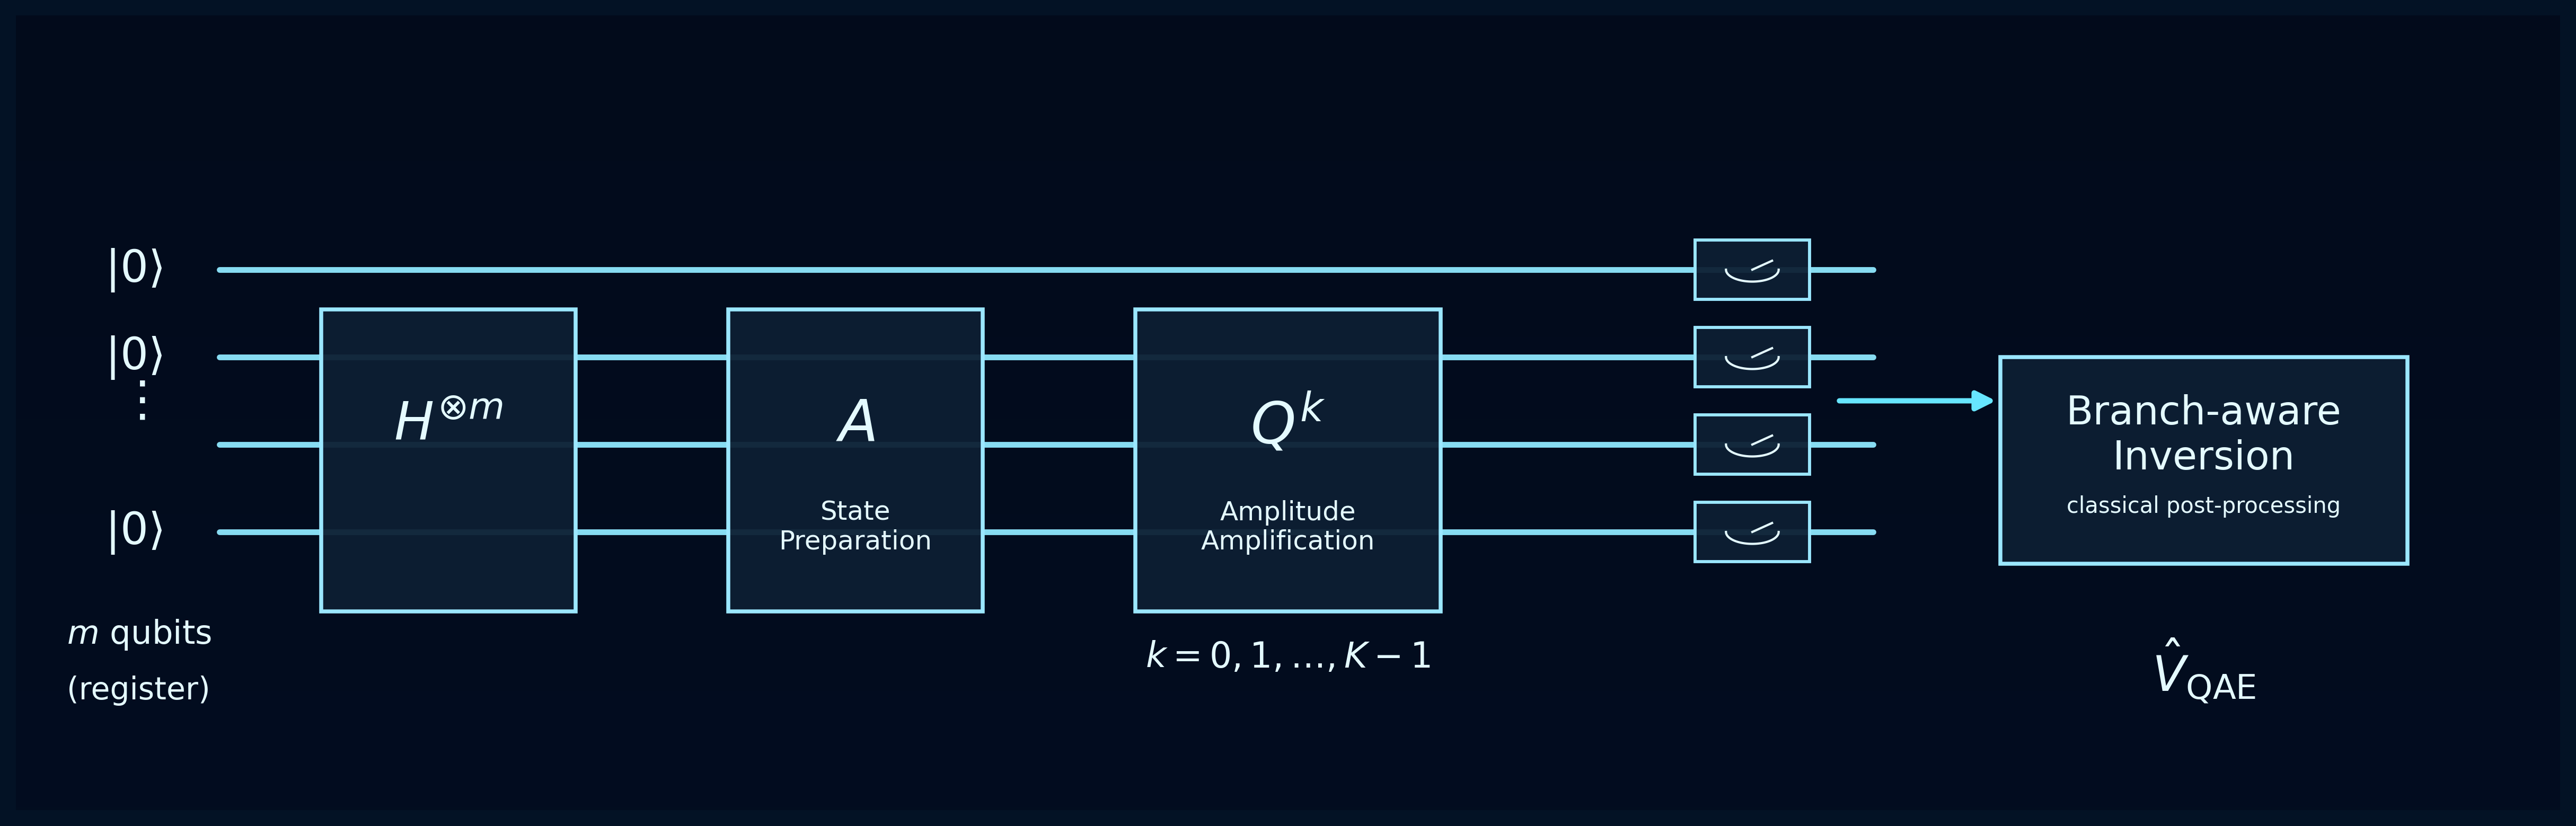

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
import numpy as np

# -------------------------------------------------
# Helpers
# -------------------------------------------------
def draw_wire(ax, x0, x1, y, color="#8fe9ff", lw=2.6, alpha=0.95, z=2):
    ax.plot([x0, x1], [y, y], color=color, lw=lw, alpha=alpha,
            solid_capstyle='round', zorder=z)

def draw_box(ax, x, y, w, h, label, sublabel=None,
             edge="#9be7ff",
             face=(0.05, 0.12, 0.20, 0.95),
             text="#e4faff",
             fontsize=24,
             subfontsize=11,
             z=5):
    rect = Rectangle((x, y), w, h,
                     linewidth=1.8,
                     edgecolor=edge,
                     facecolor=face,
                     zorder=z)
    ax.add_patch(rect)

    ax.text(x + w/2, y + h*0.62, label,
            ha='center', va='center',
            color=text, fontsize=fontsize, zorder=z+1)

    if sublabel:
        ax.text(x + w/2, y + h*0.28, sublabel,
                ha='center', va='center',
                color=text, fontsize=subfontsize, zorder=z+1)

def draw_measure(ax, x, y, w=0.045, h=0.06,
                 edge="#9be7ff",
                 text="#e4faff",
                 face=(0.05, 0.12, 0.20, 0.95),
                 z=6):
    rect = Rectangle((x, y-h/2), w, h,
                     linewidth=1.4,
                     edgecolor=edge,
                     facecolor=face,
                     zorder=z)
    ax.add_patch(rect)

    t = np.linspace(np.pi, 2*np.pi, 100)
    rx, ry = w*0.23, h*0.20
    cx, cy = x + w*0.50, y
    ax.plot(cx + rx*np.cos(t), cy + ry*np.sin(t),
            color=text, lw=1.0, zorder=z+1)
    ax.plot([cx, cx + rx*0.75], [cy, cy + ry*0.75],
            color=text, lw=1.0, zorder=z+1)

def draw_arrow(ax, x0, y0, x1, y1, color="#67e6ff", lw=2.4, z=7):
    arr = FancyArrowPatch((x0, y0), (x1, y1),
                          arrowstyle='-|>',
                          mutation_scale=18,
                          linewidth=lw,
                          color=color,
                          zorder=z)
    ax.add_patch(arr)

# -------------------------------------------------
# Figure
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 5), dpi=300)
fig.patch.set_facecolor("#031225")
ax.set_facecolor("#031225")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# subtle dark gradient background
nx, ny = 1400, 500
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, ny)
X, Y = np.meshgrid(x, y)

grad = 0.03 + 0.08*(1 - Y)
R = 0.01 + 0.015*grad
G = 0.04 + 0.10*grad
B = 0.10 + 0.22*grad
bg = np.dstack([R, G, B])

ax.imshow(bg, extent=[0, 1, 0, 1], origin="lower", aspect="auto", zorder=0)

# -------------------------------------------------
# Circuit layout
# -------------------------------------------------
wire_ys = [0.68, 0.57, 0.46, 0.35]
x_left = 0.08
x_right_measure = 0.73

# ket labels
ax.text(0.035, wire_ys[0], r"$|0\rangle$", color="#e4faff", fontsize=20, va='center')
ax.text(0.035, wire_ys[1], r"$|0\rangle$", color="#e4faff", fontsize=20, va='center')
ax.text(0.040, (wire_ys[1] + wire_ys[2]) / 2, r"$\vdots$", color="#e4faff", fontsize=22, va='center')
ax.text(0.035, wire_ys[3], r"$|0\rangle$", color="#e4faff", fontsize=20, va='center')
ax.text(0.020, 0.21, r"$m$ qubits", color="#e4faff", fontsize=15)
ax.text(0.020, 0.14, r"(register)", color="#e4faff", fontsize=14)

# wires
for yy in wire_ys:
    draw_wire(ax, x_left, x_right_measure, yy)

# blocks
block_y = 0.25
block_h = 0.38

draw_box(ax, 0.12, block_y, 0.10, block_h, r"$H^{\otimes m}$",
         fontsize=24)

draw_box(ax, 0.28, block_y, 0.10, block_h, r"$A$",
         sublabel="State\nPreparation",
         fontsize=26, subfontsize=12)

draw_box(ax, 0.44, block_y, 0.12, block_h, r"$Q^k$",
         sublabel="Amplitude\nAmplification",
         fontsize=26, subfontsize=12)

# iteration label
ax.text(0.50, 0.18, r"$k = 0, 1, \ldots, K-1$",
        color="#e4faff", fontsize=16, ha='center')

# measurement stack
mx = 0.66
for yy in wire_ys:
    draw_measure(ax, mx, yy, w=0.045, h=0.075)

# classical arrow
draw_arrow(ax, 0.715, 0.515, 0.78, 0.515)

# classical block
draw_box(ax, 0.78, 0.31, 0.16, 0.26,
         "Branch-aware\nInversion",
         sublabel="classical post-processing",
         fontsize=18, subfontsize=10)

# output estimate
ax.text(0.86, 0.15, r"$\hat{V}_{\mathrm{QAE}}$",
        color="#e4faff", fontsize=22, ha='center')

# -------------------------------------------------
# Save
# -------------------------------------------------
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.savefig("qae_circuit_only.png",
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.02,
            facecolor=fig.get_facecolor())
plt.show()

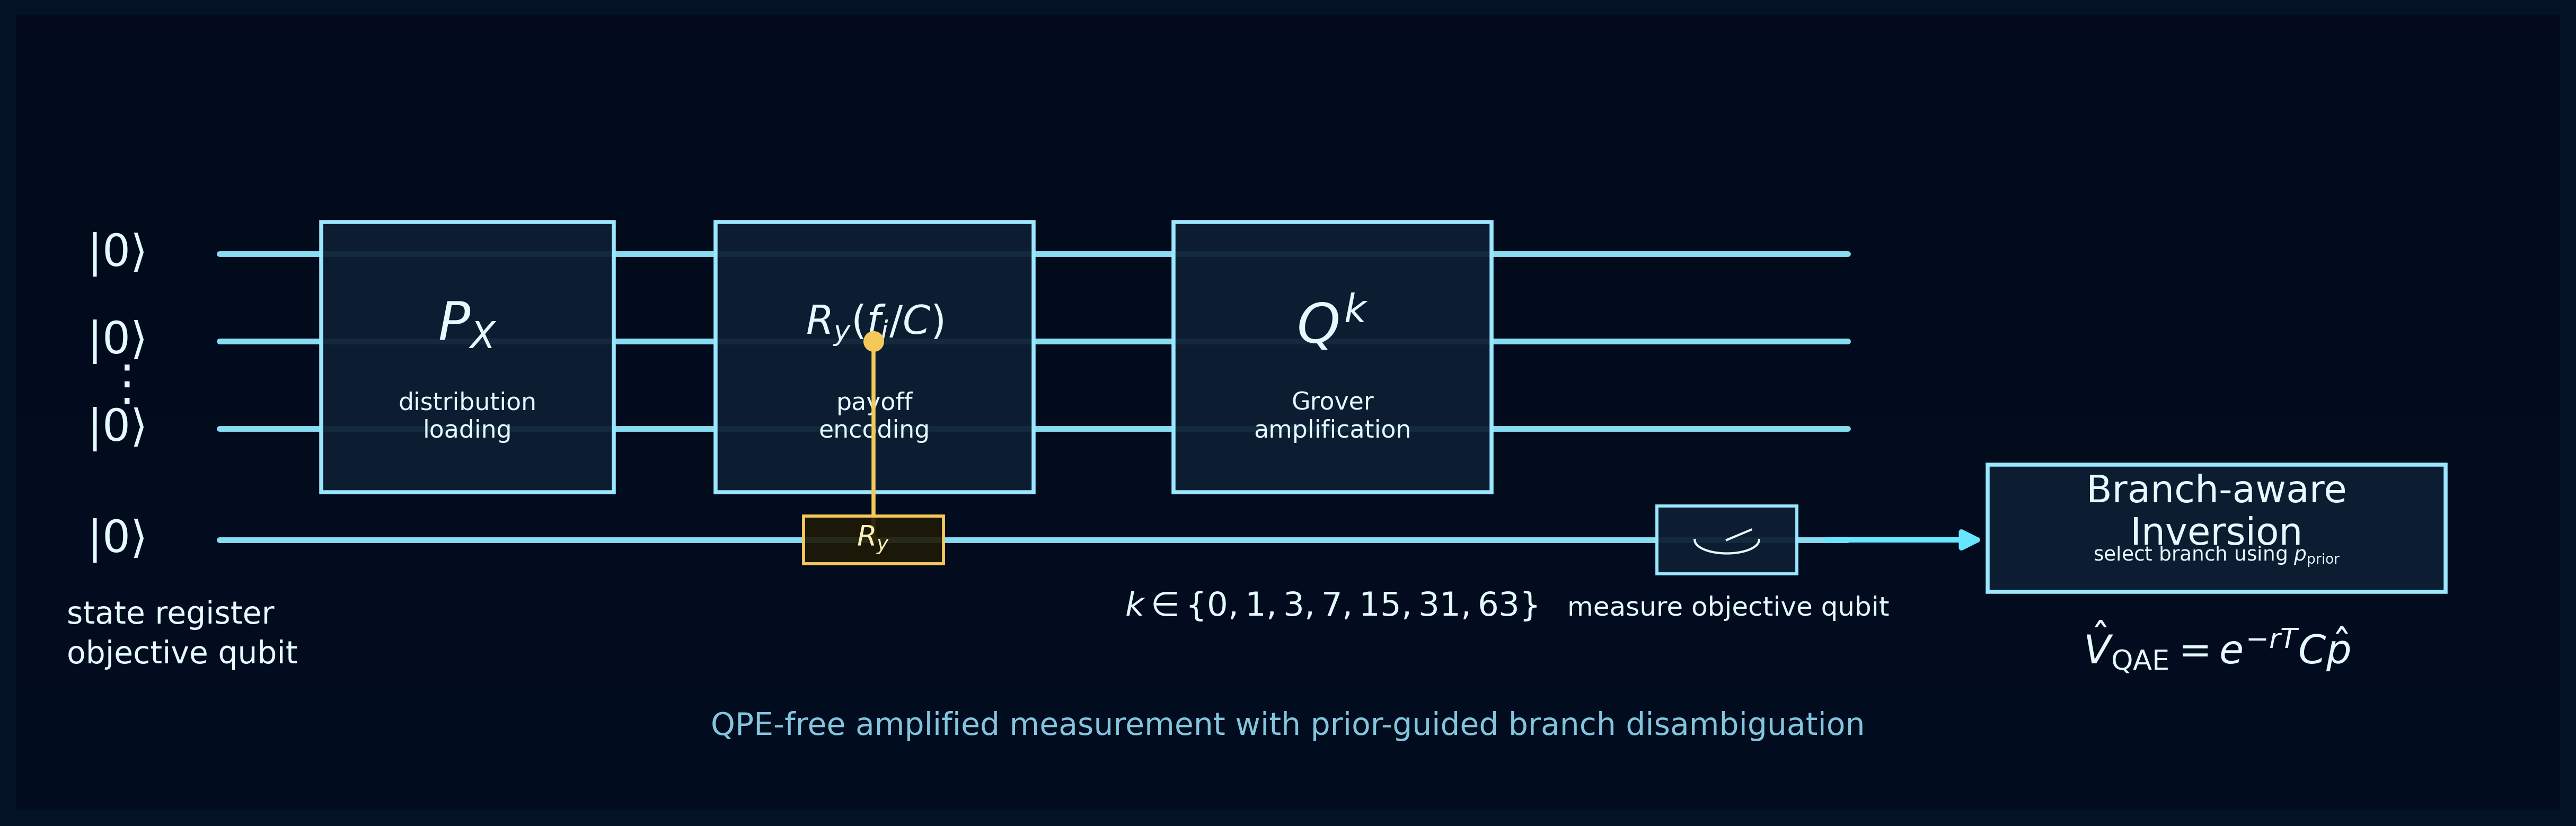

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
import numpy as np

# -------------------------------------------------
# Helpers
# -------------------------------------------------
def draw_wire(ax, x0, x1, y, color="#8fe9ff", lw=2.6, alpha=0.95, z=2):
    ax.plot([x0, x1], [y, y], color=color, lw=lw, alpha=alpha,
            solid_capstyle='round', zorder=z)

def draw_box(ax, x, y, w, h, label, sublabel=None,
             edge="#9be7ff",
             face=(0.05, 0.12, 0.20, 0.95),
             text="#e4faff",
             fontsize=22,
             subfontsize=10,
             z=5):
    rect = Rectangle((x, y), w, h,
                     linewidth=1.8,
                     edgecolor=edge,
                     facecolor=face,
                     zorder=z)
    ax.add_patch(rect)

    ax.text(x + w/2, y + h*0.62, label,
            ha='center', va='center',
            color=text, fontsize=fontsize, zorder=z+1)

    if sublabel:
        ax.text(x + w/2, y + h*0.28, sublabel,
                ha='center', va='center',
                color=text, fontsize=subfontsize, zorder=z+1)

def draw_measure(ax, x, y, w=0.050, h=0.080,
                 edge="#9be7ff",
                 text="#e4faff",
                 face=(0.05, 0.12, 0.20, 0.95),
                 z=6):
    rect = Rectangle((x, y-h/2), w, h,
                     linewidth=1.4,
                     edgecolor=edge,
                     facecolor=face,
                     zorder=z)
    ax.add_patch(rect)

    t = np.linspace(np.pi, 2*np.pi, 100)
    rx, ry = w*0.23, h*0.20
    cx, cy = x + w*0.50, y
    ax.plot(cx + rx*np.cos(t), cy + ry*np.sin(t),
            color=text, lw=1.0, zorder=z+1)
    ax.plot([cx, cx + rx*0.75], [cy, cy + ry*0.75],
            color=text, lw=1.0, zorder=z+1)

def draw_arrow(ax, x0, y0, x1, y1, color="#67e6ff", lw=2.4, z=7):
    arr = FancyArrowPatch((x0, y0), (x1, y1),
                          arrowstyle='-|>',
                          mutation_scale=18,
                          linewidth=lw,
                          color=color,
                          zorder=z)
    ax.add_patch(arr)

def draw_controlled_rotation(ax, x, y_control, y_target,
                             color="#f5c85a", z=7):
    # control dot
    ax.scatter([x], [y_control], s=70, color=color, zorder=z)
    # vertical line
    ax.plot([x, x], [y_target, y_control], color=color, lw=1.8, zorder=z)
    # target rotation box
    w, h = 0.055, 0.060
    rect = Rectangle((x - w/2, y_target - h/2), w, h,
                     linewidth=1.4,
                     edgecolor=color,
                     facecolor=(0.12, 0.10, 0.03, 0.92),
                     zorder=z)
    ax.add_patch(rect)
    ax.text(x, y_target, r"$R_y$", color="#fff0b8",
            fontsize=13, ha="center", va="center", zorder=z+1)

# -------------------------------------------------
# Figure
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 5), dpi=300)
fig.patch.set_facecolor("#031225")
ax.set_facecolor("#031225")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# subtle dark gradient background
nx, ny = 1400, 500
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, ny)
X, Y = np.meshgrid(x, y)

grad = 0.03 + 0.08*(1 - Y)
R = 0.01 + 0.015*grad
G = 0.04 + 0.10*grad
B = 0.10 + 0.22*grad
bg = np.dstack([R, G, B])
ax.imshow(bg, extent=[0, 1, 0, 1], origin="lower", aspect="auto", zorder=0)

# -------------------------------------------------
# Circuit layout
# -------------------------------------------------
# Three state-register wires + one objective qubit
state_ys = [0.70, 0.59, 0.48]
obj_y = 0.34
wire_ys = state_ys + [obj_y]

x_left = 0.08
x_right_measure = 0.72

# Labels
ax.text(0.028, state_ys[0], r"$|0\rangle$", color="#e4faff", fontsize=20, va="center")
ax.text(0.028, state_ys[1], r"$|0\rangle$", color="#e4faff", fontsize=20, va="center")
ax.text(0.034, (state_ys[1] + state_ys[2]) / 2, r"$\vdots$", color="#e4faff", fontsize=22, va="center")
ax.text(0.028, state_ys[2], r"$|0\rangle$", color="#e4faff", fontsize=20, va="center")
ax.text(0.028, obj_y, r"$|0\rangle$", color="#e4faff", fontsize=20, va="center")

ax.text(0.020, 0.235, "state register", color="#e4faff", fontsize=14)
ax.text(0.020, 0.185, "objective qubit", color="#e4faff", fontsize=14)

# Wires
for yy in wire_ys:
    draw_wire(ax, x_left, x_right_measure, yy)

# Blocks
block_y = 0.40
block_h = 0.34

draw_box(ax, 0.12, block_y, 0.115, block_h,
         r"$P_X$",
         sublabel="distribution\nloading",
         fontsize=24,
         subfontsize=11)

draw_box(ax, 0.275, block_y, 0.125, block_h,
         r"$R_y(f_i/C)$",
         sublabel="payoff\nencoding",
         fontsize=18,
         subfontsize=11)

# controlled payoff-encoding visual cue
draw_controlled_rotation(ax, x=0.337, y_control=state_ys[1], y_target=obj_y)

draw_box(ax, 0.455, block_y, 0.125, block_h,
         r"$Q^k$",
         sublabel="Grover\namplification",
         fontsize=25,
         subfontsize=11)

ax.text(0.517, 0.245, r"$k \in \{0,1,3,7,15,31,63\}$",
        color="#e4faff", fontsize=15, ha="center")

# Measure only objective qubit
mx = 0.645
draw_measure(ax, mx, obj_y, w=0.055, h=0.085)

ax.text(mx + 0.028, 0.245, r"measure objective qubit",
        color="#e4faff", fontsize=12, ha="center")

# Classical arrow to branch-aware inversion
draw_arrow(ax, 0.710, obj_y, 0.775, obj_y)

# Classical processing block
draw_box(ax, 0.775, 0.275, 0.18, 0.16,
         "Branch-aware\nInversion",
         sublabel=r"select branch using $p_{\mathrm{prior}}$",
         fontsize=17,
         subfontsize=9)

# Output estimate
ax.text(0.865, 0.185, r"$\hat{V}_{\mathrm{QAE}}=e^{-rT}C\hat{p}$",
        color="#e4faff", fontsize=18, ha="center")

# Optional subtle note under circuit
ax.text(0.50, 0.095,
        r"QPE-free amplified measurement with prior-guided branch disambiguation",
        color="#9be7ff", fontsize=14, ha="center", alpha=0.85)

# -------------------------------------------------
# Save
# -------------------------------------------------
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.savefig("qae_branch_aware_cover_circuit.png",
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.02,
            facecolor=fig.get_facecolor())
plt.show()

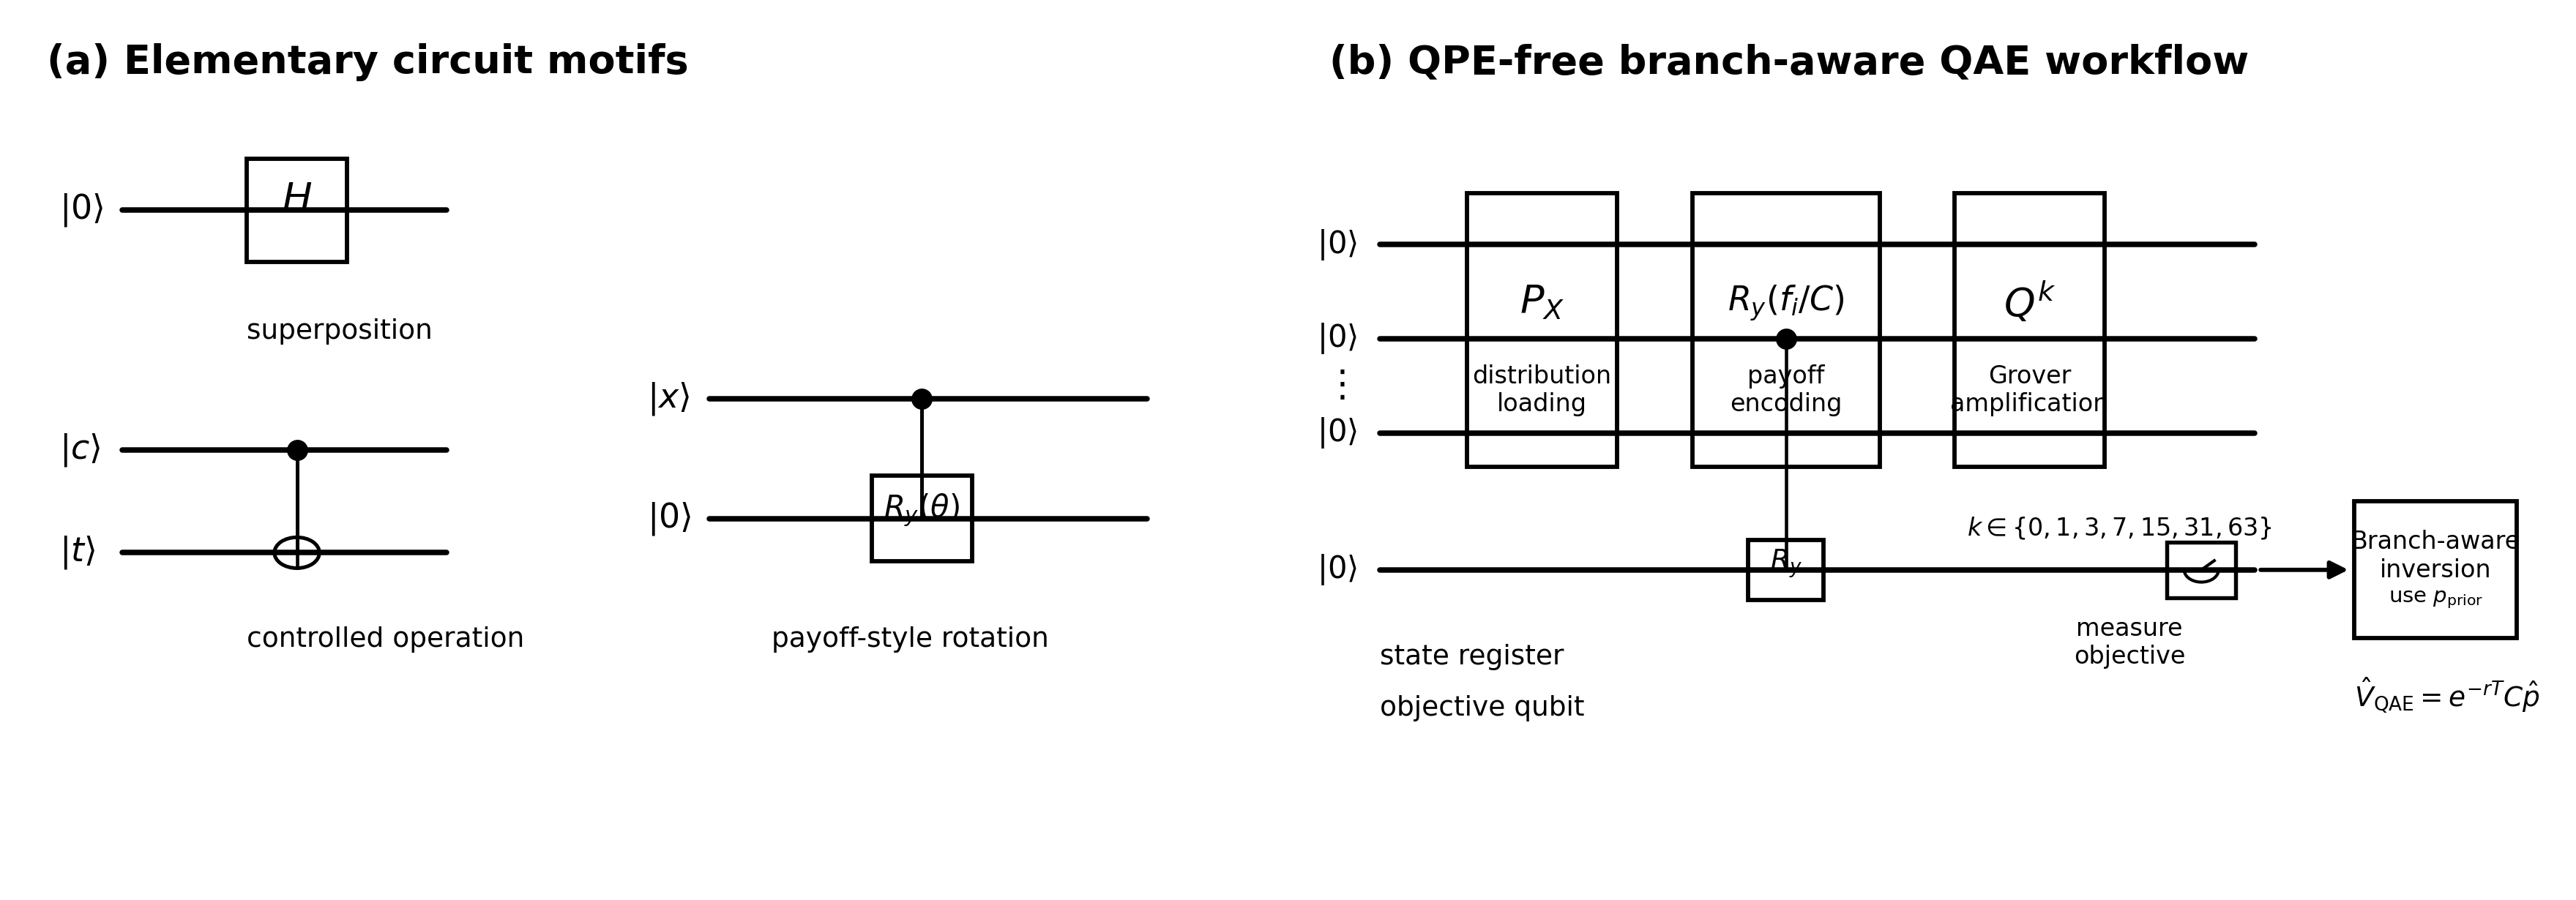

Saved: appendix_a_corrected_qae_circuit.png / .pdf


In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
import numpy as np

# -------------------------------------------------
# Helper functions
# -------------------------------------------------
def wire(ax, x0, x1, y, lw=1.8):
    ax.plot([x0, x1], [y, y], color="black", lw=lw, solid_capstyle="round")

def box(ax, x, y, w, h, text, fontsize=12, subtext=None, subfontsize=8):
    rect = Rectangle((x, y), w, h, fill=False, linewidth=1.4, edgecolor="black")
    ax.add_patch(rect)
    ax.text(x+w/2, y+h*0.60, text, ha="center", va="center", fontsize=fontsize)
    if subtext:
        ax.text(x+w/2, y+h*0.28, subtext, ha="center", va="center", fontsize=subfontsize)

def control_dot(ax, x, y):
    ax.scatter([x], [y], s=35, color="black", zorder=5)

def target_cross(ax, x, y, r=0.018):
    circle = plt.Circle((x, y), r, fill=False, color="black", lw=1.2)
    ax.add_patch(circle)
    ax.plot([x-r, x+r], [y, y], color="black", lw=1.1)
    ax.plot([x, x], [y-r, y+r], color="black", lw=1.1)

def measure(ax, x, y, w=0.055, h=0.060):
    rect = Rectangle((x, y-h/2), w, h, fill=False, linewidth=1.3, edgecolor="black")
    ax.add_patch(rect)
    t = np.linspace(np.pi, 2*np.pi, 50)
    cx, cy = x+w/2, y
    rx, ry = w*0.25, h*0.22
    ax.plot(cx + rx*np.cos(t), cy + ry*np.sin(t), color="black", lw=1.0)
    ax.plot([cx, cx+rx*0.75], [cy, cy+ry*0.75], color="black", lw=1.0)

def arrow(ax, x0, y0, x1, y1):
    arr = FancyArrowPatch((x0, y0), (x1, y1),
                          arrowstyle="-|>", mutation_scale=12,
                          linewidth=1.4, color="black")
    ax.add_patch(arr)

# -------------------------------------------------
# Figure setup
# -------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), dpi=300)
for ax in axes:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

# -------------------------------------------------
# Panel (a): elementary gates
# -------------------------------------------------
ax = axes[0]
ax.text(0.02, 0.94, "(a) Elementary circuit motifs", fontsize=13, fontweight="bold")

# Hadamard
wire(ax, 0.08, 0.34, 0.78)
ax.text(0.03, 0.78, r"$|0\rangle$", va="center", fontsize=11)
box(ax, 0.18, 0.72, 0.08, 0.12, r"$H$", fontsize=13)
ax.text(0.18, 0.63, "superposition", fontsize=9)

# CNOT
wire(ax, 0.08, 0.34, 0.50)
wire(ax, 0.08, 0.34, 0.38)
ax.text(0.03, 0.50, r"$|c\rangle$", va="center", fontsize=11)
ax.text(0.03, 0.38, r"$|t\rangle$", va="center", fontsize=11)
control_dot(ax, 0.22, 0.50)
target_cross(ax, 0.22, 0.38)
ax.plot([0.22, 0.22], [0.38, 0.50], color="black", lw=1.2)
ax.text(0.18, 0.27, "controlled operation", fontsize=9)

# Controlled Ry
wire(ax, 0.55, 0.90, 0.56)
wire(ax, 0.55, 0.90, 0.42)
ax.text(0.50, 0.56, r"$|x\rangle$", va="center", fontsize=11)
ax.text(0.50, 0.42, r"$|0\rangle$", va="center", fontsize=11)
control_dot(ax, 0.72, 0.56)
box(ax, 0.68, 0.37, 0.08, 0.10, r"$R_y(\theta)$", fontsize=10)
ax.plot([0.72, 0.72], [0.42, 0.56], color="black", lw=1.2)
ax.text(0.60, 0.27, "payoff-style rotation", fontsize=9)

# -------------------------------------------------
# Panel (b): QPE-free branch-aware QAE workflow
# -------------------------------------------------
ax = axes[1]
ax.text(0.02, 0.94, "(b) QPE-free branch-aware QAE workflow", fontsize=13, fontweight="bold")

state_ys = [0.74, 0.63, 0.52]
obj_y = 0.36
ys = state_ys + [obj_y]

for y in ys:
    wire(ax, 0.06, 0.76, y)

ax.text(0.01, state_ys[0], r"$|0\rangle$", va="center", fontsize=10)
ax.text(0.01, state_ys[1], r"$|0\rangle$", va="center", fontsize=10)
ax.text(0.015, (state_ys[1]+state_ys[2])/2, r"$\vdots$", va="center", fontsize=12)
ax.text(0.01, state_ys[2], r"$|0\rangle$", va="center", fontsize=10)
ax.text(0.01, obj_y, r"$|0\rangle$", va="center", fontsize=10)

ax.text(0.06, 0.25, "state register", fontsize=9)
ax.text(0.06, 0.19, "objective qubit", fontsize=9)

box(ax, 0.13, 0.48, 0.12, 0.32, r"$P_X$", fontsize=13, subtext="distribution\nloading")
box(ax, 0.31, 0.48, 0.15, 0.32, r"$R_y(f_i/C)$", fontsize=11, subtext="payoff\nencoding")
box(ax, 0.52, 0.48, 0.12, 0.32, r"$Q^k$", fontsize=13, subtext="Grover\namplification")

# controlled rotation cue
control_dot(ax, 0.385, state_ys[1])
box(ax, 0.355, obj_y-0.035, 0.06, 0.07, r"$R_y$", fontsize=9)
ax.plot([0.385, 0.385], [obj_y, state_ys[1]], color="black", lw=1.1)

ax.text(0.53, 0.40, r"$k\in\{0,1,3,7,15,31,63\}$", fontsize=8)

# measure objective qubit
measure(ax, 0.69, obj_y, w=0.055, h=0.065)
ax.text(0.66, 0.25, "measure\nobjective", fontsize=8, ha="center")

# classical processing
arrow(ax, 0.76, obj_y, 0.84, obj_y)
box(ax, 0.84, 0.28, 0.13, 0.16, "Branch-aware\ninversion", fontsize=8, subtext=r"use $p_{\rm prior}$", subfontsize=7)
ax.text(0.84, 0.20, r"$\hat{V}_{\rm QAE}=e^{-rT}C\hat{p}$", fontsize=9)

plt.tight_layout()
plt.savefig("appendix_a_corrected_qae_circuit.png", dpi=300, bbox_inches="tight")
plt.savefig("appendix_a_corrected_qae_circuit.pdf", bbox_inches="tight")
plt.show()

print("Saved: appendix_a_corrected_qae_circuit.png / .pdf")
